### Importation des bibliothèques


In [1]:
import numpy as np
import pandas as pd
import glob
import os
import gc  
import joblib

import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from fastai.tabular.all import df_shrink
from fastcore.parallel import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.metrics import classification_report
import pandas as pd
import glob
import os

import warnings
warnings.filterwarnings("ignore")

## Chargement du dataset

In [2]:
# Paramètres
SAMPLE_SIZE = 100000  # 
folders = ['E:/01-12/', 'E:/03-11/']

donnee = []
total_rows = 0

for folder_path in folders:
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    print(f"\n Dossier: {folder_path}")
    print(f"   Fichiers trouvés: {len(csv_files)}")
    
    for file in csv_files:
        df = pd.read_csv(file, nrows=SAMPLE_SIZE)
        donnee.append(df)
        total_rows += len(df)
        
        print(f"      - {os.path.basename(file)}: {len(df):,} lignes (échantillon)")

print(f"\n" + "="*60)
print(f" TOTAL: {len(donnee)} fichiers chargés")
print(f" Total lignes: {total_rows:,}")
print("="*60)

# Concaténer tous les échantillons
df_master = pd.concat(donnee, ignore_index=True)
print(f"\n DataFrame: {df_master.shape}")


 Dossier: E:/01-12/
   Fichiers trouvés: 11
      - DrDoS_DNS.csv: 100,000 lignes (échantillon)
      - DrDoS_LDAP.csv: 100,000 lignes (échantillon)
      - DrDoS_MSSQL.csv: 100,000 lignes (échantillon)
      - DrDoS_NetBIOS.csv: 100,000 lignes (échantillon)
      - DrDoS_NTP.csv: 100,000 lignes (échantillon)
      - DrDoS_SNMP.csv: 100,000 lignes (échantillon)
      - DrDoS_SSDP.csv: 100,000 lignes (échantillon)
      - DrDoS_UDP.csv: 100,000 lignes (échantillon)
      - Syn.csv: 100,000 lignes (échantillon)
      - TFTP.csv: 100,000 lignes (échantillon)
      - UDPLag.csv: 100,000 lignes (échantillon)

 Dossier: E:/03-11/
   Fichiers trouvés: 7
      - LDAP.csv: 100,000 lignes (échantillon)
      - MSSQL.csv: 100,000 lignes (échantillon)
      - NetBIOS.csv: 100,000 lignes (échantillon)
      - Portmap.csv: 100,000 lignes (échantillon)
      - Syn.csv: 100,000 lignes (échantillon)
      - UDP.csv: 100,000 lignes (échantillon)
      - UDPLag.csv: 100,000 lignes (échantillon)

 TOTAL:

#### Standardisation des noms de colonnes

In [3]:
col_name = {
'Flow ID': 'Flow ID',
'Source IP': 'Source IP',
'Src IP':  'Source IP',
'Source Port': 'Source Port',
'Src Port': 'Source Port',
'Destination IP': 'Destination IP',
'Dst IP': 'Destination IP',
'Destination Port': 'Destination Port',
'Dst Port': 'Destination Port',
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}

#### Implementation Standardisation des noms de colonnes

In [4]:
for df in donnee:
    df.columns = df.columns.str.strip()   
    df.rename(columns=col_name, inplace=True)
[i.shape for i in donnee]

[(100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88),
 (100000, 88)]

## Sélection des caractéristiques

In [5]:
drop_columns = [ 
    "Flow ID",    
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",        
    "SimillarHTTP",           #  Colonnes d'identification
    "Inbound",                #  capturé de manière incohérente peut fausser le modele
    "Fwd Avg Bytes/Bulk",     
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",      # Colonnes constantes 0
    "Fwd URG Flags",    
    "Bwd PSH Flags",    
    "Bwd URG Flags",    
    "FIN Flag Count",   
    "PSH Flag Count",   
    "ECE Flag Count"          # Flags toujours à 0
]

In [6]:
for df in donnee:
    df.drop(columns=drop_columns, inplace=True, errors='ignore') 

In [7]:
donnee[0].dtypes


Protocol                      int64
Flow Duration                 int64
Total Fwd Packets             int64
Total Backward Packets        int64
Fwd Packets Length Total    float64
                             ...   
Idle Mean                   float64
Idle Std                    float64
Idle Max                    float64
Idle Min                    float64
Label                           str
Length: 66, dtype: object

##  Downcasting des gros CSV (reduire la taille memoire des donnees)

In [8]:
#Traitement un par un pour économiser la RAM
donnee = [df_shrink(df) for df in donnee]
donnee = parallel(f=df_shrink, items=donnee, n_workers=2, progress=True)
# Applique la fonction de réduction de mémoire sur tous les DataFrames en utilisant 2 processeurs en même temps

## Fusion des CSV en un seul DataFrame

In [9]:
df = pd.concat(donnee, ignore_index=True)

print(f"les {len(donnee)} fichiers ont été fusionnés")
print(f"Le DataFrame a Shape: {df.shape}")

#Libération de la mémoire
del donnee
gc.collect() 

les 18 fichiers ont été fusionnés
Le DataFrame a Shape: (1800000, 66)


0

In [10]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,28415,97,0,42680.0,0.0,440.0,440.0,440.0,0.000000,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,880.0,0.0,440.0,440.0,440.0,0.000000,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,48549,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,48337,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,32026,200,0,88000.0,0.0,440.0,440.0,440.0,0.000000,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799995,17,108874,4,0,1398.0,0.0,369.0,330.0,349.5,22.516661,...,-1062718972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
1799996,17,107731,4,0,1398.0,0.0,369.0,330.0,349.5,22.516661,...,-1062718972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
1799997,17,108833,4,0,1398.0,0.0,369.0,330.0,349.5,22.516661,...,-1062718972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP
1799998,17,103893,4,0,1398.0,0.0,369.0,330.0,349.5,22.516661,...,-1062718972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,UDP


In [11]:
df["Label"].unique()

<StringArray>
[    'DrDoS_DNS',        'BENIGN',    'DrDoS_LDAP',   'DrDoS_MSSQL',
 'DrDoS_NetBIOS',     'DrDoS_NTP',    'DrDoS_SNMP',    'DrDoS_SSDP',
     'DrDoS_UDP',           'Syn',          'TFTP',       'UDP-lag',
       'WebDDoS',       'NetBIOS',          'LDAP',         'MSSQL',
       'Portmap',           'UDP']
Length: 18, dtype: str

In [12]:
# Dictionnaire pour uniformiser les noms des attaques
label_replacements = {
    'DrDoS_DNS': 'DNS',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP': 'NTP',
    'DrDoS_SNMP': 'SNMP',
    'DrDoS_SSDP': 'SSDP',
    'DrDoS_UDP': 'UDP',
    'Syn': 'Syn',
    'TFTP': 'TFTP',
    'UDP-lag': 'UDP-lag',
    'NetBIOS': 'NetBIOS',
    'LDAP': 'LDAP',
    'Portmap': 'Portmap',
    'MSSQL': 'MSSQL',
    'UDP': 'UDP',
    'SSDP': 'SSDP'
}

df['Label'] = df['Label'].replace(label_replacements)

print("Comptage des étiquettes après nettoyage:")
print(df['Label'].value_counts())

Comptage des étiquettes après nettoyage:
Label
NetBIOS    299324
UDP        272961
MSSQL      213403
Syn        199964
LDAP       109901
TFTP        99989
SNMP        99956
SSDP        99886
DNS         98290
UDP-lag     95913
Portmap     95273
NTP         87466
BENIGN      27261
WebDDoS       413
Name: count, dtype: int64


##  Nettoyage des données (Gestion des valeurs manquantes, nulles et infinies)

In [13]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(106407)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800000 entries, 0 to 1799999
Data columns (total 66 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int16  
 4   Fwd Packets Length Total  float32
 5   Bwd Packets Length Total  float32
 6   Fwd Packet Length Max     float32
 7   Fwd Packet Length Min     float32
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     float32
 11  Bwd Packet Length Min     float32
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              float32
 19  Flow IAT Min              float32
 20  Fwd IAT Total             float32
 

In [15]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,3413.689952,1.502024e+06
1,1000000.000000,4.400000e+08
2,4119.549321,1.812602e+06
3,4137.617146,1.820552e+06
4,6244.925998,2.747767e+06
...,...,...
1799995,36.739717,1.284053e+04
1799996,37.129517,1.297677e+04
1799997,36.753558,1.284537e+04
1799998,38.501150,1.345615e+04


In [16]:
# 1. Compter les inf par colonne
inf_col = np.isinf(df.select_dtypes(include=np.number)).sum()
print(inf_col[inf_col > 0])

Flow Bytes/s      44058
Flow Packets/s    62349
dtype: int64


In [17]:
df.groupby("Label")["Flow Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,27261.0,inf,NaN,0.036693,5.486768e+01,1.922522e+02,8.316008e+03,inf
DNS,98290.0,inf,NaN,0.039297,6.666667e+05,2.000000e+06,2.000000e+06,inf
LDAP,109901.0,inf,NaN,0.055659,1.000000e+06,2.000000e+06,2.000000e+06,inf
MSSQL,213403.0,inf,NaN,0.034565,1.000000e+06,2.000000e+06,2.000000e+06,inf
NTP,87466.0,inf,NaN,0.030518,7.534984e+03,2.459646e+04,9.523810e+04,inf
NetBIOS,299324.0,inf,NaN,0.052723,2.000000e+06,2.000000e+06,2.000000e+06,inf
Portmap,95273.0,inf,NaN,0.042459,2.000000e+06,2.000000e+06,2.000000e+06,inf
SNMP,99956.0,inf,NaN,0.167025,1.000000e+06,2.000000e+06,2.000000e+06,inf
SSDP,99886.0,inf,NaN,0.038253,3.801125e+01,1.000000e+06,2.000000e+06,inf


In [18]:
inf_cols = ["Flow Bytes/s", "Flow Packets/s"]

for col in inf_cols:
    
    #  Remplacer les inf par la médiane
    median = df.loc[np.isfinite(df[col]), col].median()
    df[col] = df[col].replace([np.inf, -np.inf], median)
    
    #  Compresser l'échelle
    df[col] = np.log1p(df[col])

print("Inf remplacés et log1p appliqué")

Inf remplacés et log1p appliqué


In [19]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,8.135842,14.222324
1,13.815512,19.902285
2,8.323742,14.410274
3,8.328117,14.414651
4,8.739685,14.826300
...,...,...
1799995,3.630713,9.460440
1799996,3.640989,9.470993
1799997,3.631080,9.460816
1799998,3.676330,9.507266


In [20]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [21]:
df.isna().sum().sum()

np.int64(18291)

In [22]:
df.dropna(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(1303407)

In [24]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True, drop=True)

In [25]:
df.shape

(478302, 66)

In [26]:

print("CLASS DISTRIBUTION (Label)")
print("=" * 60)
print(df['Label'].value_counts())


CLASS DISTRIBUTION (Label)
Label
UDP        130117
NTP         82964
Syn         77390
UDP-lag     53982
SSDP        34550
MSSQL       28495
BENIGN      25270
DNS         19676
NetBIOS     11295
TFTP         8183
LDAP         3983
Portmap      1275
SNMP          730
WebDDoS       392
Name: count, dtype: int64


## Séparation X et y

In [27]:
y = df["Label"].copy()
X = df.drop(columns=["Label"])

print(f"Target (y) : {y.shape[0]:,} lignes, {y.nunique()} classes")
print(f"Features(X): {X.shape[0]:,} rows × {X.shape[1]} columns\n")

Target (y) : 478,302 lignes, 14 classes
Features(X): 478,302 rows × 65 columns



In [28]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 478302 entries, 0 to 478301
Data columns (total 65 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  478302 non-null  int8   
 1   Flow Duration             478302 non-null  int32  
 2   Total Fwd Packets         478302 non-null  int32  
 3   Total Backward Packets    478302 non-null  int16  
 4   Fwd Packets Length Total  478302 non-null  float32
 5   Bwd Packets Length Total  478302 non-null  float32
 6   Fwd Packet Length Max     478302 non-null  float32
 7   Fwd Packet Length Min     478302 non-null  float32
 8   Fwd Packet Length Mean    478302 non-null  float32
 9   Fwd Packet Length Std     478302 non-null  float32
 10  Bwd Packet Length Max     478302 non-null  float32
 11  Bwd Packet Length Min     478302 non-null  float32
 12  Bwd Packet Length Mean    478302 non-null  float32
 13  Bwd Packet Length Std     478302 non-null  float32
 14 

## Division entre données d'entraînement et de tes

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,stratify=y,)


## Analyse Exploratoire des Données :Exploratory Data Analysis (EDA)


In [30]:
def count_unique_values(df):
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"{col}: {unique_count}")

count_unique_values(X)

Protocol: 3
Flow Duration: 185186
Total Fwd Packets: 311
Total Backward Packets: 280
Fwd Packets Length Total: 3514
Bwd Packets Length Total: 2229
Fwd Packet Length Max: 1815
Fwd Packet Length Min: 1235
Fwd Packet Length Mean: 4748
Fwd Packet Length Std: 4238
Bwd Packet Length Max: 606
Bwd Packet Length Min: 181
Bwd Packet Length Mean: 2817
Bwd Packet Length Std: 2833
Flow Bytes/s: 180442
Flow Packets/s: 221640
Flow IAT Mean: 227235
Flow IAT Std: 312616
Flow IAT Max: 154551
Flow IAT Min: 1666
Fwd IAT Total: 179342
Fwd IAT Mean: 220412
Fwd IAT Std: 304488
Fwd IAT Max: 148846
Fwd IAT Min: 512
Bwd IAT Total: 32193
Bwd IAT Mean: 32318
Bwd IAT Std: 32375
Bwd IAT Max: 31686
Bwd IAT Min: 107
Fwd PSH Flags: 2
Fwd Header Length: 4930
Bwd Header Length: 539
Fwd Packets/s: 220791
Bwd Packets/s: 73160
Packet Length Min: 1229
Packet Length Max: 1712
Packet Length Mean: 6094
Packet Length Std: 5151
Packet Length Variance: 5151
SYN Flag Count: 2
RST Flag Count: 2
ACK Flag Count: 2
URG Flag Count: 2
C

In [31]:
cat_columns = ["Protocol", "Fwd PSH Flags", "SYN Flag Count", "RST Flag Count",  "ACK Flag Count", "URG Flag Count","CWE Flag Count"]
num_columns = [col for col in X.columns if col not in cat_columns]

### Colonnes catégorielles

          Label      Ratio
Label                     
UDP      104093  27.203828
NTP       66371  17.345501
Syn       61912  16.180179
UDP-lag   43186  11.286297
SSDP      27640   7.223481
MSSQL     22796   5.957542
BENIGN    20216   5.283281
DNS       15741   4.113778
NetBIOS    9036   2.361482
TFTP       6546   1.710742
LDAP       3186   0.832634
Portmap    1020   0.266568
SNMP        584   0.152623
WebDDoS     314   0.082061




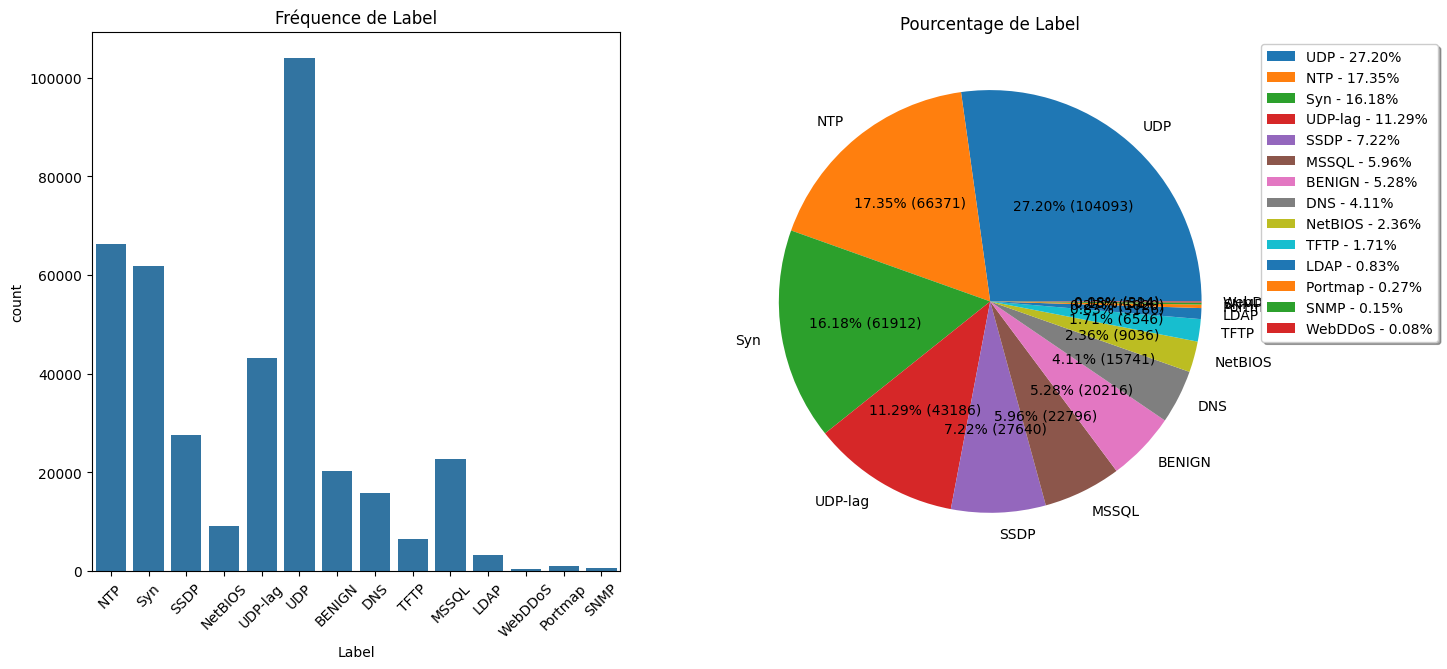

          Protocol      Ratio
Protocol                     
17          272044  71.096406
6           110223  28.805852
0              374   0.097742




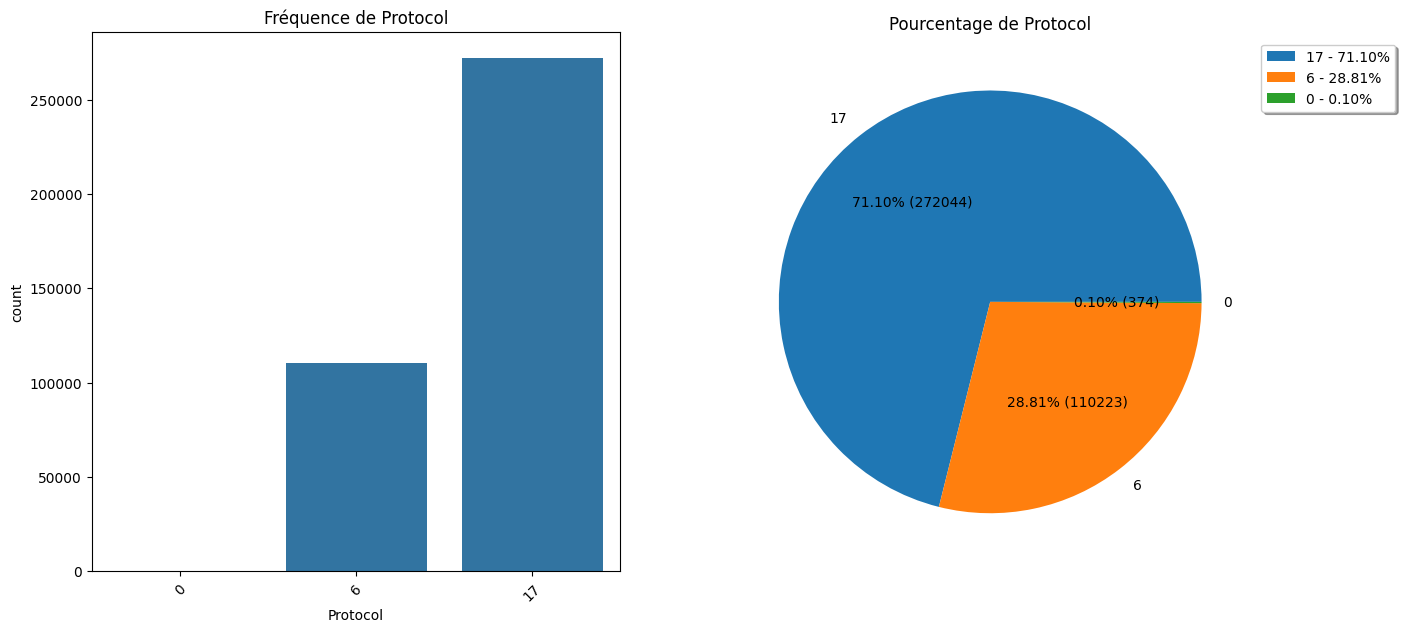

               Fwd PSH Flags      Ratio
Fwd PSH Flags                          
0                     380665  99.483589
1                       1976   0.516411




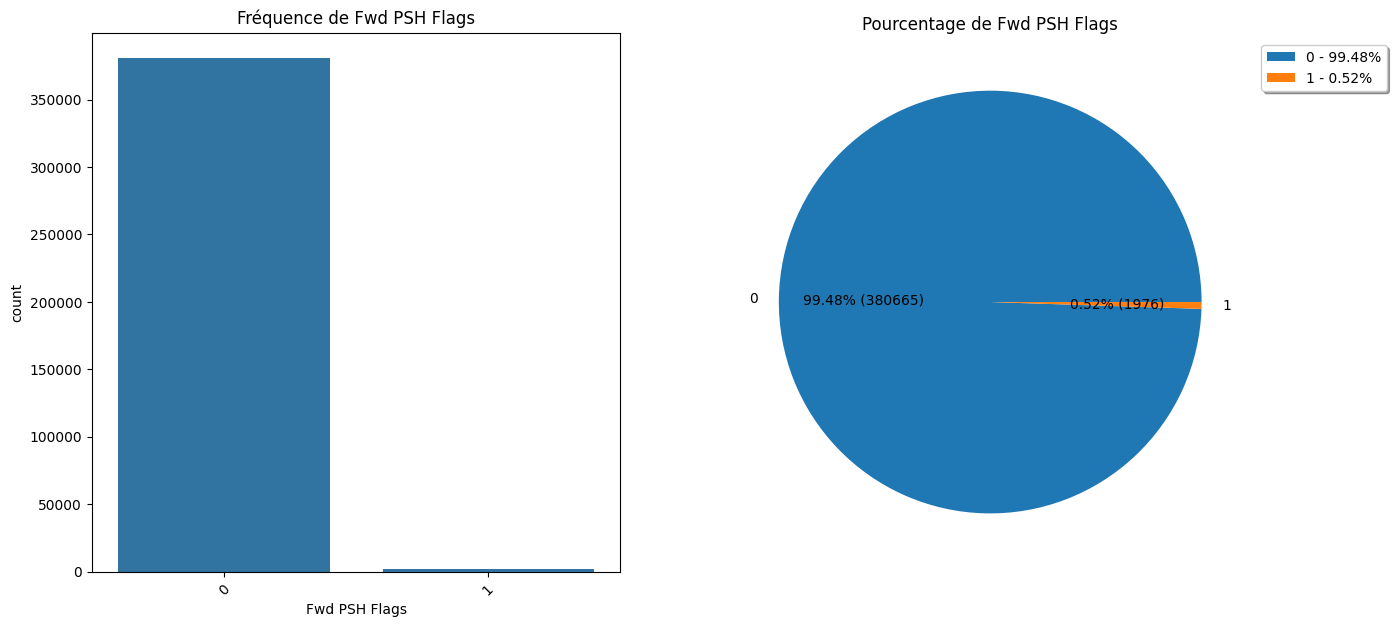

                SYN Flag Count      Ratio
SYN Flag Count                           
0                       382471  99.955572
1                          170   0.044428




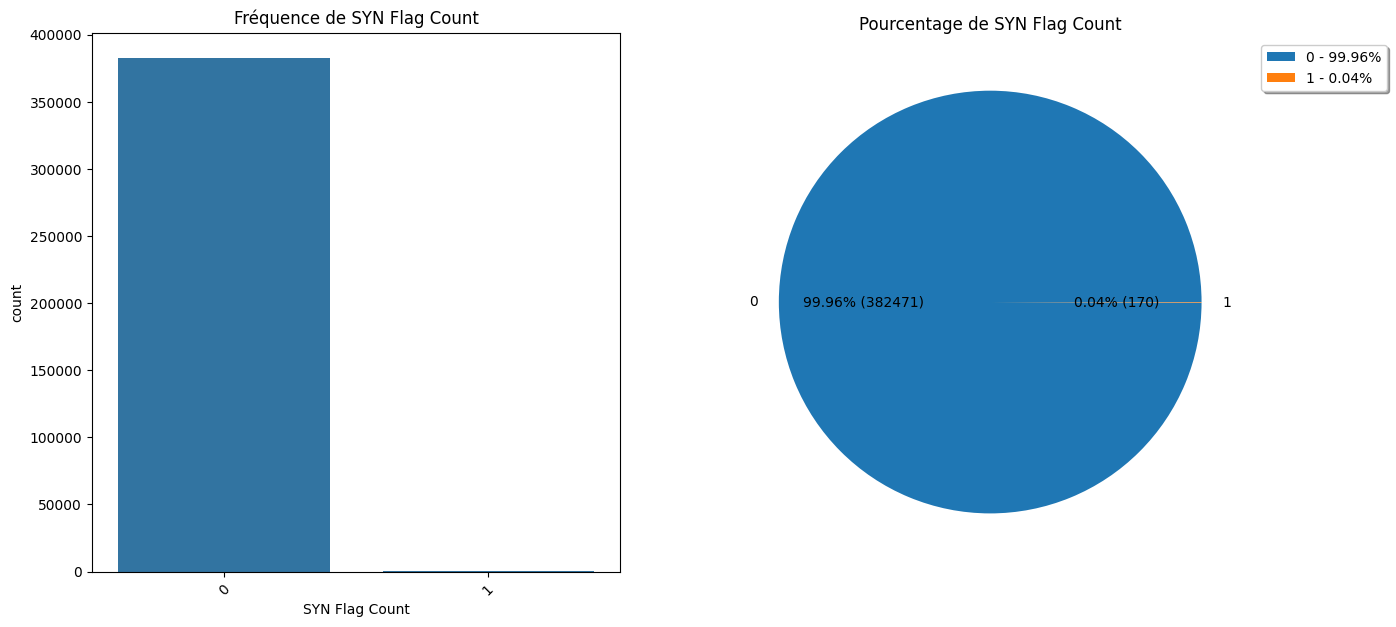

                RST Flag Count      Ratio
RST Flag Count                           
0                       380665  99.483589
1                         1976   0.516411




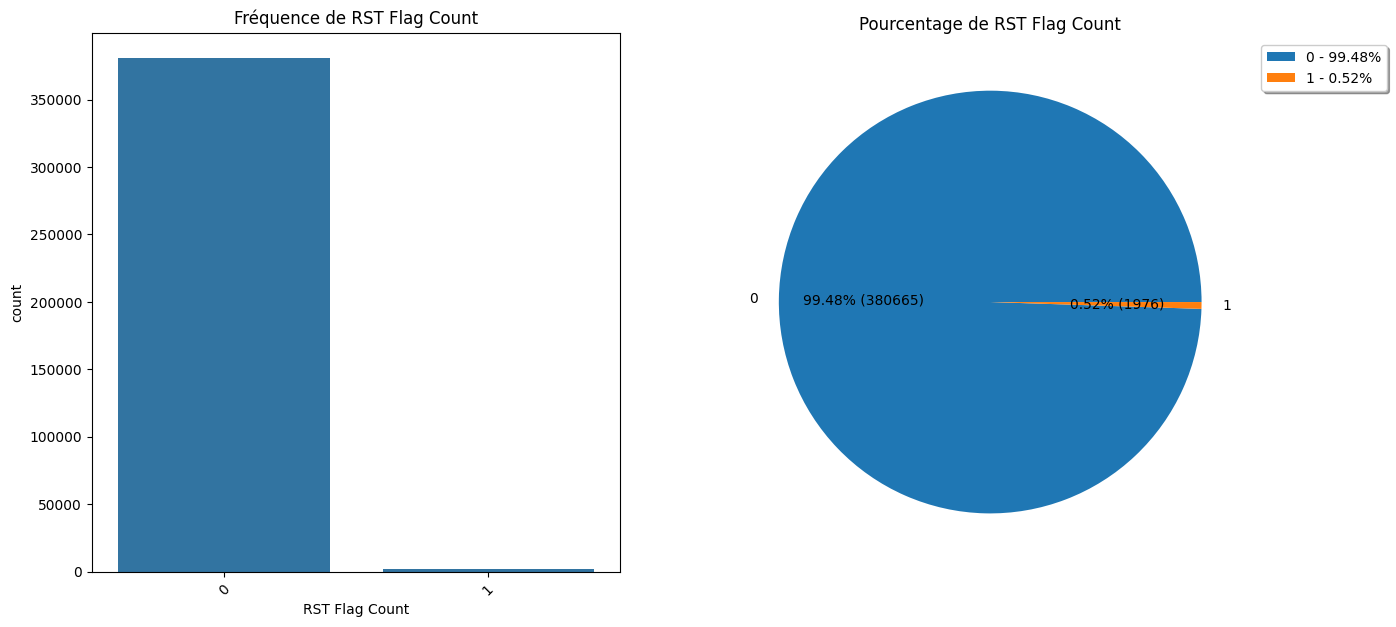

                ACK Flag Count      Ratio
ACK Flag Count                           
0                       282317  73.781168
1                       100324  26.218832




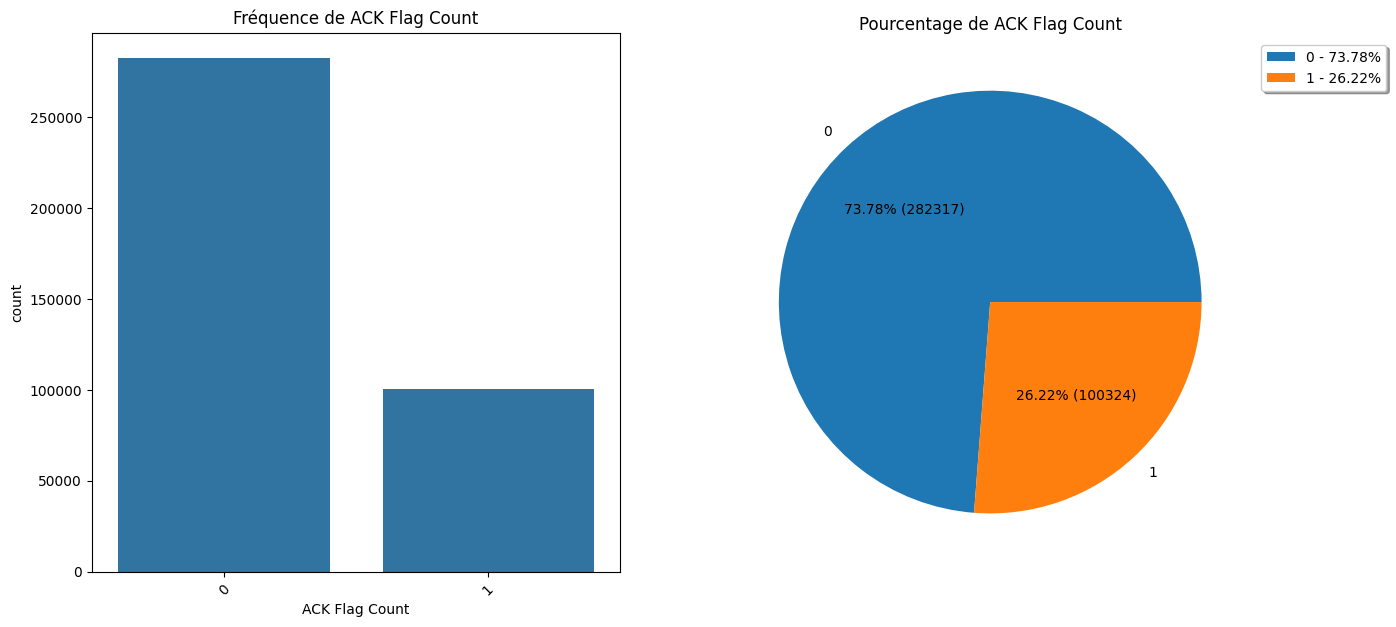

                URG Flag Count      Ratio
URG Flag Count                           
0                       372745  97.413764
1                         9896   2.586236




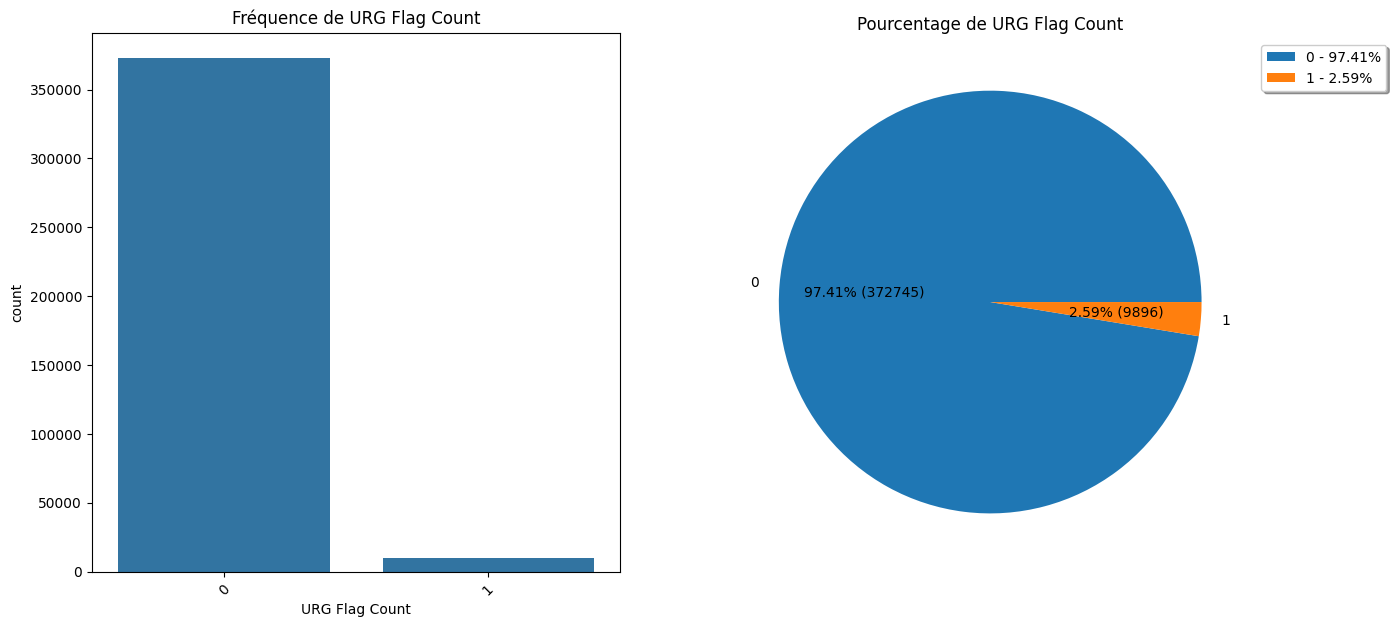

                CWE Flag Count      Ratio
CWE Flag Count                           
0                       375729  98.193607
1                         6912   1.806393




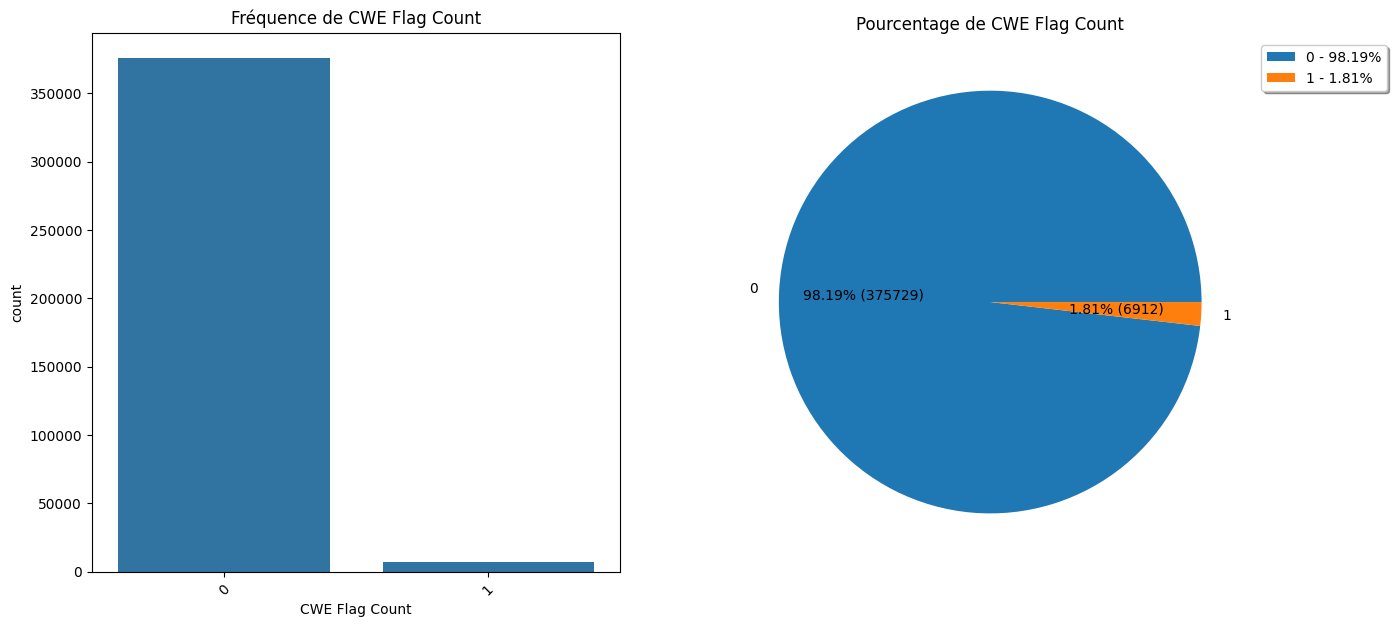

In [32]:
def resume_categoriel(donnees, colonne, graphique=False):
    print(pd.DataFrame({colonne: donnees[colonne].value_counts(), 
                        "Ratio": donnees[colonne].value_counts() / len(donnees) * 100}))
    print("\n")
    if graphique:
        fig, axes = plt.subplots(1, 2, figsize=(15, 7))
        
        # Graphique 1 : Diagramme en barres
        plt.subplot(1, 2, 1)
        sns.countplot(x=colonne, data=donnees)
        plt.xticks(rotation=45)
        plt.title(f"Fréquence de {colonne}")

        # Graphique 2 : Camembert
        plt.subplot(1, 2, 2)
        valeurs = donnees[colonne].value_counts()
        plt.pie(x=valeurs, labels=valeurs.index, 
                autopct=lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(valeurs)))
        plt.legend(labels=[f'{index} - {valeur / sum(valeurs) * 100:.2f}%' 
                          for index, valeur in zip(valeurs.index, valeurs)],
                   loc="upper left", bbox_to_anchor=(1, 1),
                   fancybox=True, shadow=True, ncol=1)
        plt.title(f"Pourcentage de {colonne}")
        plt.show(block=True)

# Exécution
resume_categoriel(pd.DataFrame(y_train, columns=['Label']), "Label", graphique=True)

for col in cat_columns:
    resume_categoriel(X_train, col, graphique=True)

### Colonnes numeriques

In [33]:
# Graphiques de Distribution pour les colonnes numériques
def histogramme(donnees, col, ax):
    sns.histplot(x=col, data=donnees, kde=True, ax=ax)
    ax.set_title(f"Histogramme de {col}")

def distribution(donnees, col, ax):
    sns.distplot(donnees[col], ax=ax)
    ax.set_title(f"Distribution de {col}")

def courbe_densite(donnees, col, ax):
    sns.kdeplot(x=col, data=donnees, ax=ax)
    ax.set_title(f"Courbe de densité de {col}")

# Graphiques Relationnels pour les colonnes numériques
def nuage_points(donnees, col, ax):
    sns.scatterplot(x=col, data=donnees, ax=ax)
    ax.set_title(f"Nuage de points de {col}")

def graphique_ligne(donnees, col, ax):
    sns.lineplot(x=col, data=donnees, ax=ax)
    ax.set_title(f"Graphique en ligne de {col}")

# Graphiques Catégoriels pour les colonnes catégorielles
def camembert(donnees, col, ax):
    valeurs = donnees[col].value_counts()
    ax.pie(x=valeurs, labels=valeurs.index, 
           autopct=lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(valeurs)))
    ax.legend(labels=[f'{index} - {valeur / sum(valeurs) * 100:.2f}%' 
                      for index, valeur in zip(valeurs.index, valeurs)],
              loc="upper left", bbox_to_anchor=(1, 1),
              fancybox=True, shadow=True, ncol=1)
    ax.set_title(f"Camembert de {col}")

def graphique_barres(donnees, col, ax):
    sns.countplot(x=col, data=donnees, ax=ax)
    ax.set_title(f"Graphique en barres de {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

def boite_moustaches(donnees, col, ax):
    sns.boxplot(y=col, data=donnees, ax=ax)
    ax.set_title(f"Boîte à moustaches de {col}")

def graphique_violon(donnees, col, ax):
    sns.violinplot(y=col, data=donnees, ax=ax)
    ax.set_title(f"Graphique en violon de {col}")

def graphique_essaim(donnees, col, ax):
    sns.swarmplot(y=col, data=donnees, ax=ax)
    ax.set_title(f"Graphique en essaim de {col}")

# Graphiques Matriciels pour les colonnes numériques
def carte_chaleur(donnees, taille):
    if taille: plt.figure(figsize=taille)
    sns.heatmap(donnees.corr(), annot=True, fmt=".1f", 
                cmap="Blues", annot_kws={"size": 12})
    plt.title("Matrice de corrélation")
    plt.show()

def graphique_comparaison(donnees, col_normale, col_label):
    plt.figure(figsize=(10, 6), dpi=80)
    plt.bar(list(dict(donnees[col_normale].value_counts()).keys()), 
            dict(donnees[col_normale].value_counts()).values(), color='r')
    plt.bar(list(dict(donnees[col_normale][donnees[col_label] == 1].value_counts()).keys()),
            dict(donnees[col_normale][donnees[col_label] == 1].value_counts()).values(), 
            color='b')
    plt.xlabel(col_normale)
    plt.ylabel("Occurences")
    plt.title(f"{col_normale} vs {col_label}")
    plt.show()

def grille_graphiques(donnees, fonction_graphique, taille=(12,4), n_col=1):
    if len(donnees.columns) == 0:
        return
    n_lignes = (len(donnees.columns) + n_col - 1)
    fig, axes = plt.subplots(n_lignes, n_col, 
                             figsize=(taille[0]*n_col, taille[1]*n_lignes))
    if len(donnees.columns) == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(donnees.columns):
        fonction_graphique(donnees, col, axes[i])

    for j in range(i+1, n_lignes*n_col):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [34]:
#grille_graphiques(X_train[num_columns], histogramme, size=(12, 4), n_col=2)

In [35]:
#grille_graphiques(X_train[num_columns], distribution, size=(2, 4), n_col=6)

###  Analyse de la taille des paquets et de la durée des flux

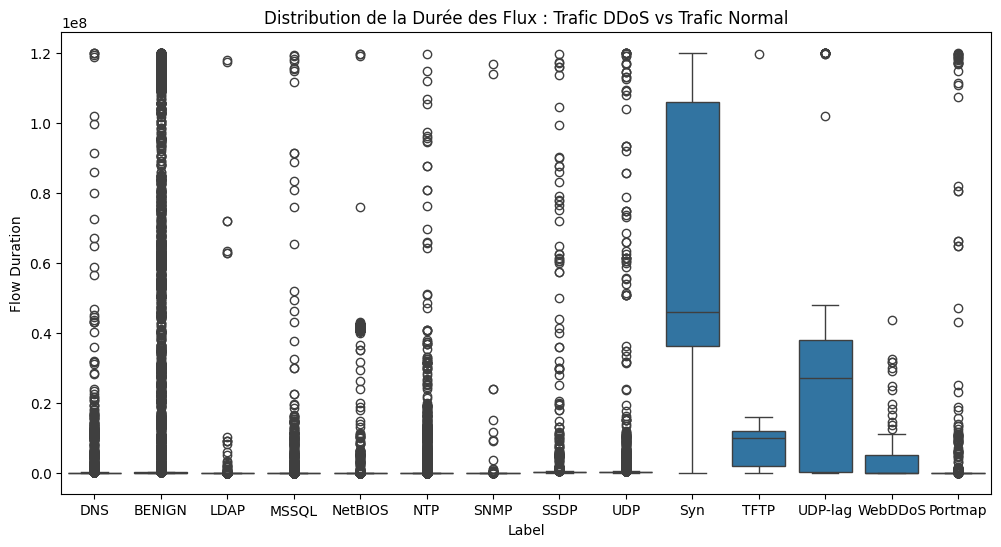

In [36]:
# Boxplot de la durée des flux par type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Duration", data=df)
plt.title("Distribution de la Durée des Flux : Trafic DDoS vs Trafic Normal")
plt.show()

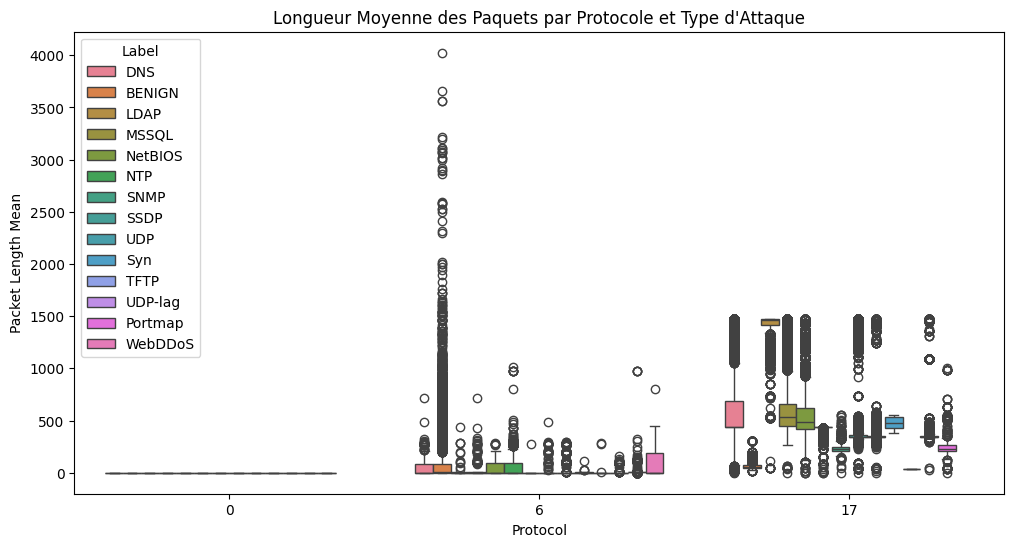

In [37]:
# Boxplot de la taille moyenne des paquets par protocole et type de trafic
plt.figure(figsize=(12, 6))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=df)
plt.title("Longueur Moyenne des Paquets par Protocole et Type d'Attaque")
plt.show()

###  Flags TCP et motifs d'attaque

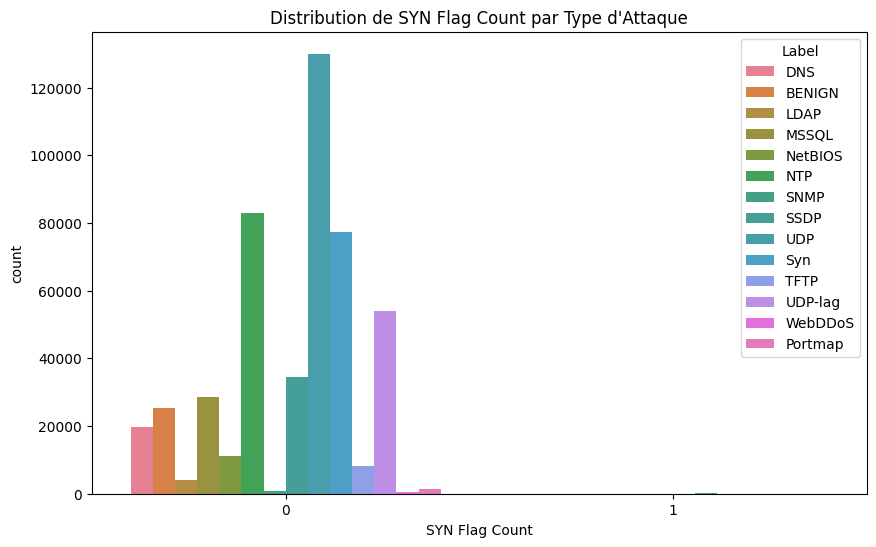

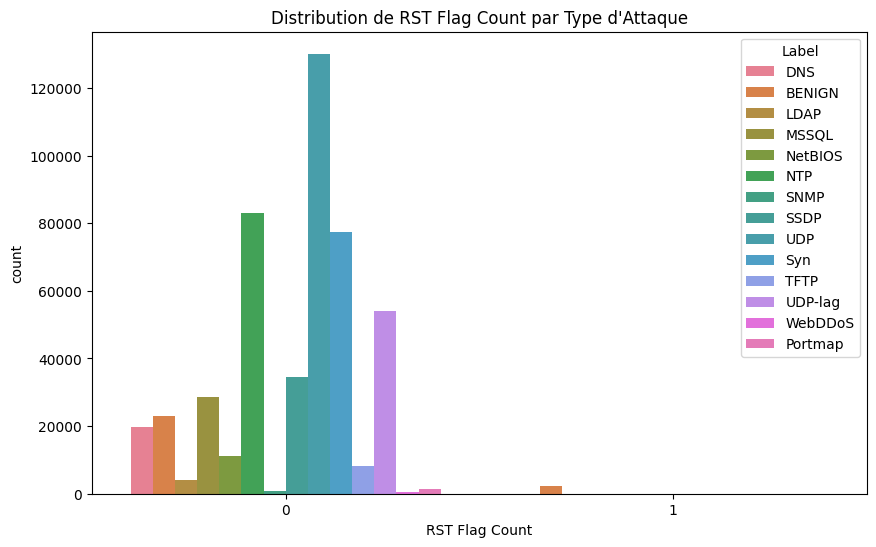

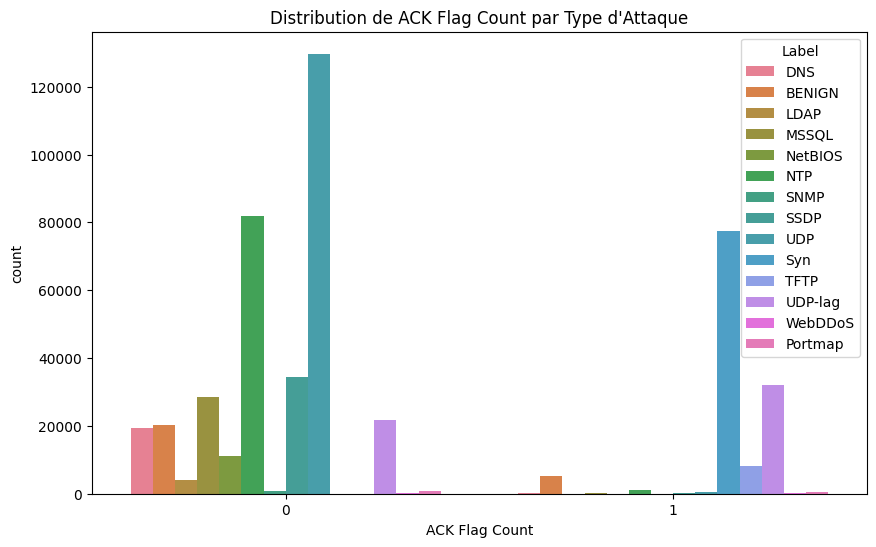

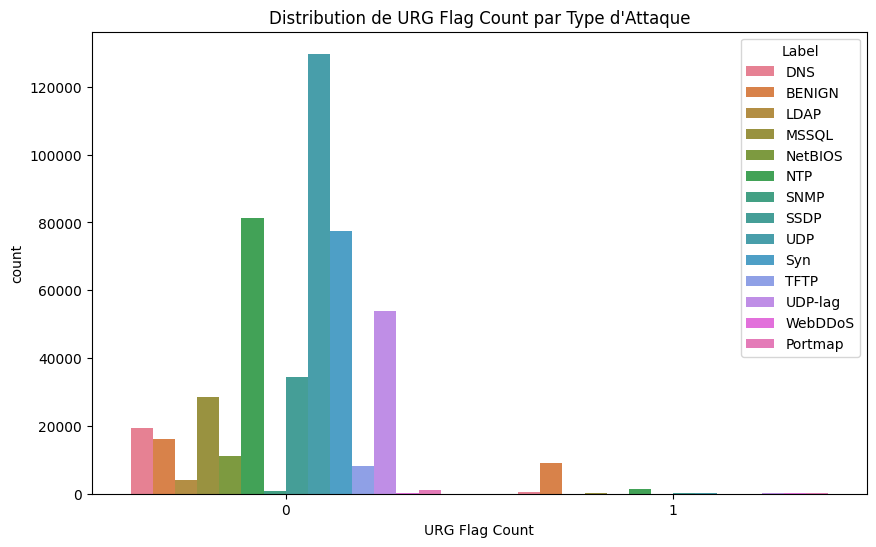

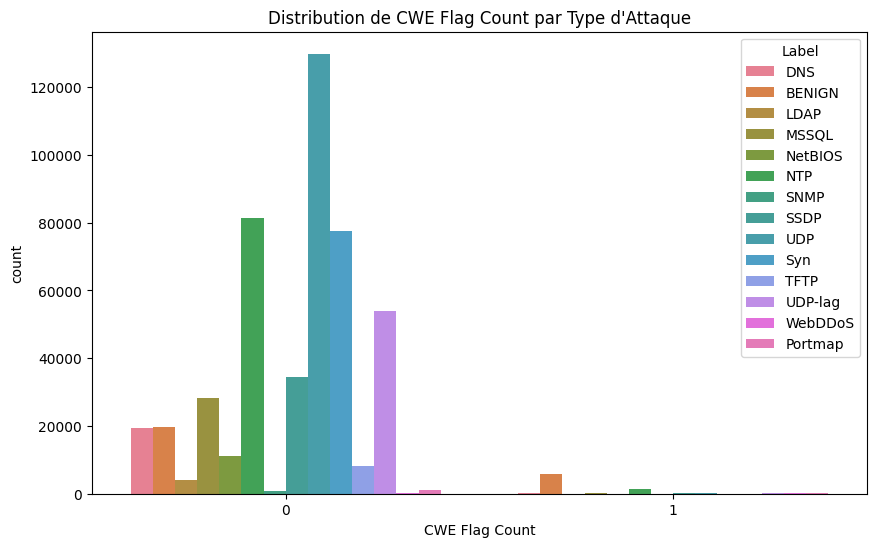

In [38]:
# Compter le nombre d'occurrences de chaque flag dans le trafic attaque vs normal
colonnes_flags = [col for col in df.columns if "Flag " in col]

for flag in colonnes_flags:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=flag, hue="Label", data=df)
    plt.title(f"Distribution de {flag} par Type d'Attaque")
    plt.show()

## # Déséquilibre des Classes, Mise à l'Échelle, Extraction de Features, Encodage

### SMOTE

In [39]:
# Ou utilise SMOTE qui génère des données synthétiques
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [40]:
print("Distribution après SMOTE :")
print(pd.Series(y_train).value_counts())

Distribution après SMOTE :
Label
NTP        104093
Syn        104093
SSDP       104093
NetBIOS    104093
UDP-lag    104093
UDP        104093
BENIGN     104093
DNS        104093
TFTP       104093
MSSQL      104093
LDAP       104093
WebDDoS    104093
Portmap    104093
SNMP       104093
Name: count, dtype: int64


### Standard Scaling

In [41]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train[num_columns]),
    columns=num_columns,
    index=X_train.index,
)
X_test = pd.DataFrame(
    scaler.transform(X_test[num_columns]),
    columns=num_columns,
    index=X_test.index,
)

print(f"{len(num_columns)} colonnes numériques normalisée")

58 colonnes numériques normalisée


In [42]:
#sauvegarde l'état appris du normaliseur 
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### SÉLECTION DE FEATURES : SelectKBest + Random Forest

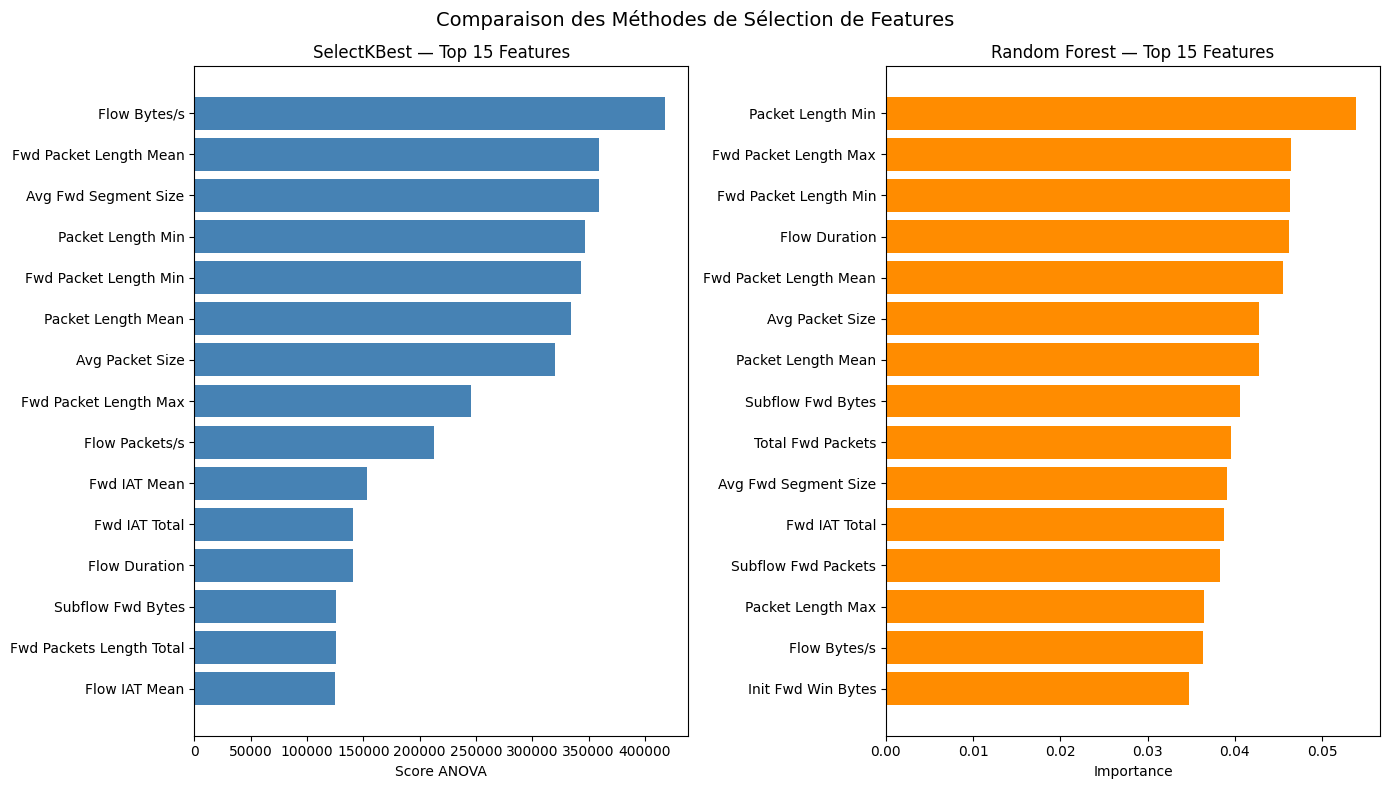

In [43]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

N_FEATURES = 20

# Préparation
noms_features  = X_train.columns.tolist()
X_array        = np.nan_to_num(X_train.values.astype(np.float32), nan=0, posinf=0, neginf=0)
y_array        = LabelEncoder().fit_transform(y_train.astype(object)).astype(np.int32)

# 1. SelectKBest
selecteur     = SelectKBest(f_classif, k=N_FEATURES).fit(X_array, y_array)
indices_kbest = selecteur.get_support(indices=True)
resultats_kbest = pd.DataFrame({
    'Feature'     : [noms_features[i] for i in indices_kbest],
    'Score ANOVA' : selecteur.scores_[indices_kbest]
}).sort_values('Score ANOVA', ascending=False)

# 2. Random Forest
foret = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
foret.fit(X_array, y_array)
indices_rf   = np.argsort(foret.feature_importances_)[::-1][:N_FEATURES]
resultats_rf = pd.DataFrame({
    'Feature'    : [noms_features[i] for i in indices_rf],
    'Importance' : foret.feature_importances_[indices_rf]
})

# 3. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
ax1.barh(resultats_kbest['Feature'][:15][::-1], resultats_kbest['Score ANOVA'][:15][::-1], color='steelblue')
ax1.set_title('SelectKBest — Top 15 Features')
ax1.set_xlabel('Score ANOVA')
ax2.barh(resultats_rf['Feature'][:15][::-1], resultats_rf['Importance'][:15][::-1], color='darkorange')
ax2.set_title('Random Forest — Top 15 Features')
ax2.set_xlabel('Importance')
plt.suptitle('Comparaison des Méthodes de Sélection de Features', fontsize=14)
plt.tight_layout()
plt.show()



In [44]:
meilleures_features_rf = resultats_rf['Feature'].tolist()
joblib.dump(meilleures_features_rf, 'features_selectionnees.pkl') 
 
X_train = X_train[meilleures_features_rf]  
X_test  = X_test[meilleures_features_rf]

### Encodage de la variable cible

In [45]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Affichage du mapping
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print("Correspondance Labels → Chiffres :")
for nom, chiffre in mapping.items():
    print(f"  {nom} → {chiffre}")

Correspondance Labels → Chiffres :
  BENIGN → 0
  DNS → 1
  LDAP → 2
  MSSQL → 3
  NTP → 4
  NetBIOS → 5
  Portmap → 6
  SNMP → 7
  SSDP → 8
  Syn → 9
  TFTP → 10
  UDP → 11
  UDP-lag → 12
  WebDDoS → 13


In [46]:
joblib.dump(label_encoder, 'encodeur_labels.pkl')

['encodeur_labels.pkl']

## Entraînement des Modèles

In [47]:
# Dictionnaire global pour stocker les résultats de tous les modèles
model_evaluations = {}

In [48]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=3e-4, # # taux d'apprentissage initial : 0.0003
    decay_steps=10000,          # fréquence de décroissance (à ajuster selon la taille du dataset)
    decay_rate=0.9              # facteur de décroissance
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [49]:
# Convertir en numpy array de manière explicite
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train_encoded)
y_test = np.array(y_test_encoded)

1. RANDOM FOREST

In [50]:
print("=" * 60)
print("ENTRAÎNEMENT - RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train_encoded)
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest - Accuracy: {accuracy_score(y_test_encoded, y_pred_rf)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))

model_evaluations['Random Forest'] = {
    "y_pred": y_pred_rf,
    "y_proba": rf_model.predict_proba(X_test),
    "cv_score": accuracy_score(y_test_encoded, y_pred_rf)
}

ENTRAÎNEMENT - RANDOM FOREST
Random Forest - Accuracy: 80.70%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99      5054
         DNS       0.80      0.68      0.73      3935
        LDAP       0.35      0.88      0.50       797
       MSSQL       0.67      0.65      0.66      5699
         NTP       0.99      0.95      0.97     16593
     NetBIOS       0.29      0.31      0.30      2259
     Portmap       0.32      0.45      0.38       255
        SNMP       0.19      0.71      0.30       146
        SSDP       0.48      0.18      0.26      6910
         Syn       1.00      0.97      0.98     15478
        TFTP       0.66      0.99      0.79      1637
         UDP       0.73      0.93      0.82     26024
     UDP-lag       0.97      0.57      0.72     10796
     WebDDoS       0.14      0.92      0.24        78

    accuracy                           0.81     95661
   macro avg       0.61      0.73      0.62     

2. SVM (Support Vector Machine)

print("\n" + "=" * 60)
print("ENTRAÎNEMENT - SVM")
print("=" * 60)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  
    random_state=42,
    class_weight='balanced'
)

svm_model.fit(X_train, y_train_encoded)
y_pred_svm = svm_model.predict(X_test)

print(f" SVM - Accuracy: {accuracy_score(y_test_encoded, y_pred_svm)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder.classes_))

model_evaluations['SVM'] = {
    "y_pred": y_pred_svm,
    "y_proba": svm_model.predict_proba(X_test),
    "cv_score": accuracy_score(y_test_encoded, y_pred_svm)
}

 3. LOGISTIC REGRESSION

In [ ]:
print("ENTRAÎNEMENT - LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train_encoded)
y_pred_lr = lr_model.predict(X_test)

print(f" Logistic Regression - Accuracy: {accuracy_score(y_test_encoded, y_pred_lr)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_lr, target_names=label_encoder.classes_))

model_evaluations['Logistic Regression'] = {
    "y_pred": y_pred_lr,
    "y_proba": lr_model.predict_proba(X_test),
    "cv_score": accuracy_score(y_test_encoded, y_pred_lr)
}

ENTRAÎNEMENT - LOGISTIC REGRESSION


### 4. Long Short-Term Memory (LSTM) Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[1]
n_classes = 13

lstm_model = Sequential(name="DDoS_LSTM")

lstm_model.add(LSTM(64, return_sequences=True, input_shape=(n_features, 1)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(64))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(n_classes, activation='softmax'))

lstm_model.compile(
    optimizer=Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("LSTM Architecture Built!")
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train, y_train_encoded,
    epochs=50, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

print(f"Recording evaluations for {lstm_model.name}...")

y_proba = lstm_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

pseudo_cv_score = history_lstm.history['val_accuracy'][-1] 

model_evaluations[lstm_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

LSTM Architecture Built!


Model: "DDoS_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,429 (236.05 KB)

 Trainable params: 60,173 (235.05 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.3411 - loss: 2.0229 - val_accuracy: 0.0000e+00 - val_loss: 2.6944
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5383 - loss: 1.2971 - val_accuracy: 0.0000e+00 - val_loss: 2.8158
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5899 - loss: 1.0798 - val_accuracy: 0.0000e+00 - val_loss: 2.8543
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6158 - loss: 0.9888 - val_accuracy: 0.0000e+00 - val_loss: 2.8543
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6300 - loss: 0.9378 - val_accuracy: 0.1698 - val_loss: 2.7260
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6528 - loss: 0.8849 - val_accuracy: 0.2398 - val_loss: 2.2907
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6603 - loss: 0.8648 - val_accuracy: 0.2875 - val_loss: 2.0002
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6657 - loss: 0.8372 - val_accu

### 6. Multi-Layer Perceptron (MLP) Classifier

In [ ]:
from tensorflow.keras.layers import Flatten

mlp_model = Sequential(name="DDoS_MLP")

# Flatten the (n_features, 1) input to a flat vector of (n_features)
mlp_model.add(Flatten(input_shape=(n_features, 1)))

# Deep Dense Network
mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.4))

mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.4))

mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dropout(0.3))

mlp_model.add(Dense(n_classes, activation='softmax'))

mlp_model.compile(
    optimizer=Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("MLP Architecture Built!")
mlp_model.summary()

# Training
history_mlp = mlp_model.fit(
    X_train, y_train_encoded,
    epochs=20, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

print(f"Recording evaluations for {mlp_model.name}...")

y_proba = mlp_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

pseudo_cv_score = history_mlp.history['val_accuracy'][-1] 

model_evaluations[mlp_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

MLP Architecture Built!


Model: "DDoS_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,725 (702.05 KB)

 Trainable params: 178,189 (696.05 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4639 - loss: 1.6778 - val_accuracy: 0.3106 - val_loss: 2.1922
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6206 - loss: 1.0300 - val_accuracy: 0.3106 - val_loss: 1.8462
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6551 - loss: 0.9187 - val_accuracy: 0.3108 - val_loss: 1.5566
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6696 - loss: 0.8702 - val_accuracy: 0.3118 - val_loss: 1.3677
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6881 - loss: 0.8161 - val_accuracy: 0.3138 - val_loss: 1.2285
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6934 - loss: 0.7921 - val_accuracy: 0.3389 - val_loss: 1.1040
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7051 - loss: 0.7593 - val_accuracy: 0.5566 - val_loss: 0.9994
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7111 - loss: 0.7335 - val_accuracy: 0.5521 - val

### 7. CNN Model

In [ ]:

n_features = X_train.shape[1] 
n_classes = 13 

cnn_model = Sequential(name="DDoS_1D_CNN")

cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_features, 1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))


cnn_model.add(Flatten())

cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(3648, activation='relu'))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(64, activation='relu'))

cnn_model.add(Dense(n_classes, activation='softmax'))

custom_adam = Adam(learning_rate=lr_schedule, beta_1=0.9)

cnn_model.compile(
    optimizer=custom_adam, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Model architecture built successfully!\n")
cnn_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)


print("\nStarting model training...")

history = cnn_model.fit(
    X_train, 
    y_train_encoded,
    epochs=50, 
    batch_size=256, 
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)


print("\nEvaluating model on test data...")
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%\n")

print("Generating Detailed Classification Report...")

y_proba = cnn_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)


print(f"Recording evaluations for {cnn_model.name}...")

pseudo_cv_score = history.history['val_accuracy'][-1] 

model_evaluations[cnn_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

Model architecture built successfully!



Model: "DDoS_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3648)           │       704,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       467,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,192,845 (4.55 MB)

 Trainable params: 1,192,845 (4.55 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4190 - loss: 1.6650 - val_accuracy: 0.3093 - val_loss: 2.7228
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6230 - loss: 1.0033 - val_accuracy: 0.3113 - val_loss: 1.5718
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.6640 - loss: 0.8515 - val_accuracy: 0.3121 - val_loss: 1.3355
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6909 - loss: 0.7864 - val_accuracy: 0.3443 - val_loss: 1.2015
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7047 - loss: 0.7425 - val_accuracy: 0.3424 - val_loss: 1.1301
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7183 - loss: 0.7115 - val_accuracy: 0.4618 - val_loss: 0.8743
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7250 - loss: 0.6866 - val_accuracy: 0.4489 - val_loss: 0.9900
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7318 - loss: 0.671

Évaluation des modèles:   0%|          | 0/6 [00:00<?, ?it/s]

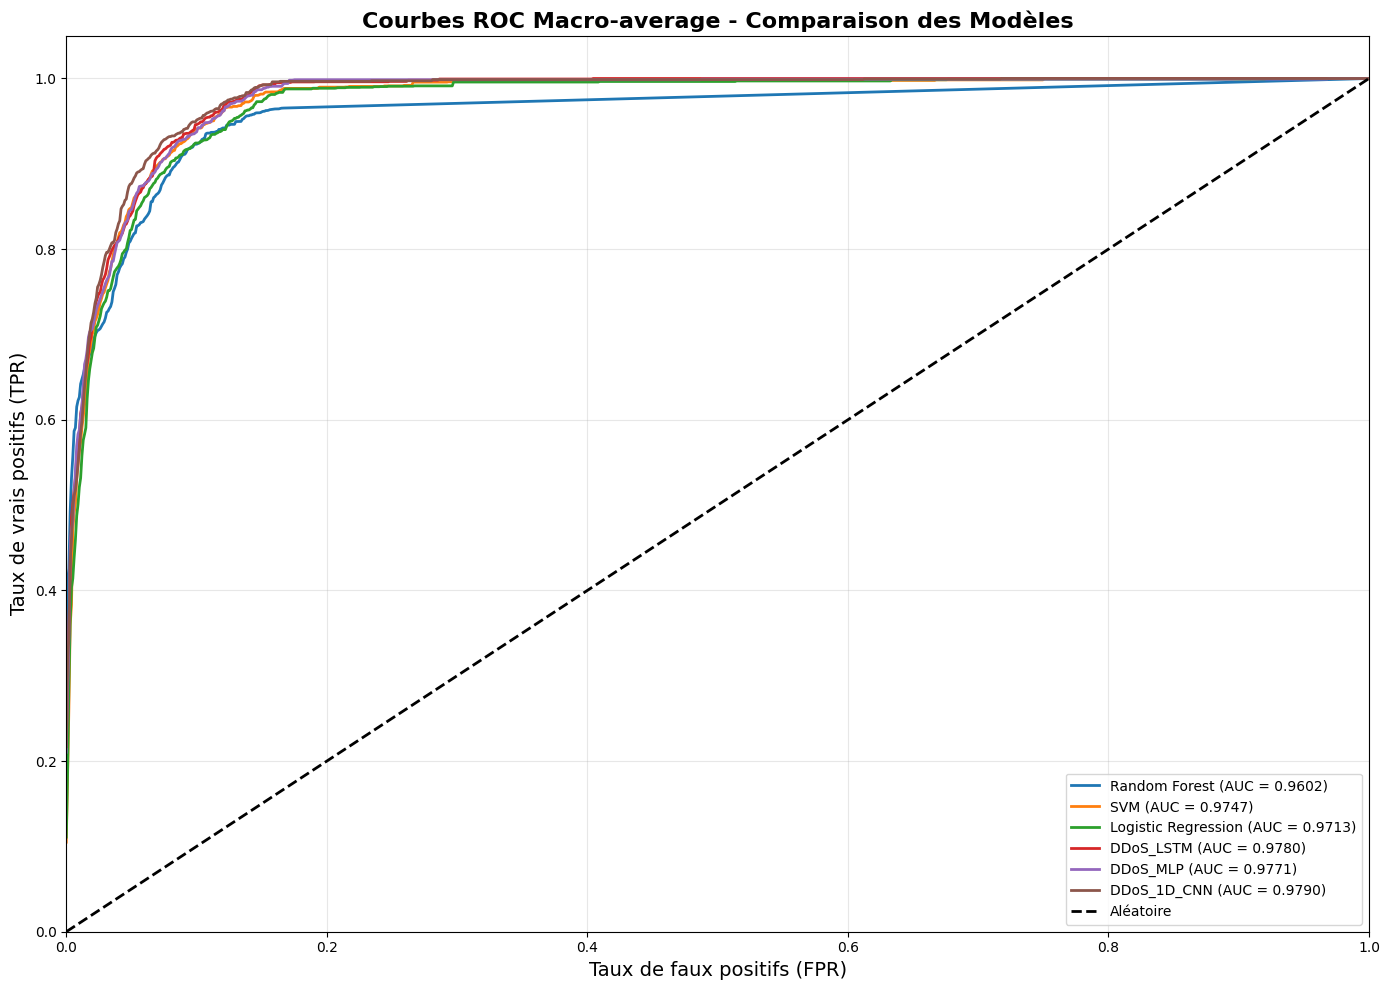


🏆 RÉSULTATS FINAUX DES MODÈLES 🏆


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Score
0,Random Forest,77.76%,78.55%,77.76%,77.94%,97.50%,77.76%
1,SVM,76.36%,73.61%,76.36%,73.67%,97.26%,76.36%
2,Logistic Regression,74.62%,75.36%,74.62%,72.93%,96.91%,74.62%
3,DDoS_LSTM,75.94%,74.41%,75.94%,73.70%,97.83%,57.94%
4,DDoS_MLP,74.34%,73.36%,74.34%,72.36%,97.67%,68.30%
5,DDoS_1D_CNN,73.36%,74.93%,73.36%,70.09%,97.99%,67.38%



🏆 MEILLEUR MODÈLE
🎯 Modèle: Random Forest
📊 Accuracy: 77.76%
🎯 F1-Score: 77.94%


In [ ]:
# =========================================================
# FONCTION D'ÉVALUATION - UNIQUEMENT VISUALISATION
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from IPython.display import display
from sklearn.metrics import auc

def evaluate_all_models(eval_dict, y_true, n_classes):
    scores_list = []
    
    plt.figure(figsize=(14, 10))
    
    for name, data in tqdm(eval_dict.items(), desc="Évaluation des modèles"):
        y_pred = data["y_pred"]
        y_proba = data["y_proba"]
        cv_score = data["cv_score"]
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
      
        scores_list.append({
            "Model": name,
            "Accuracy": f"{accuracy*100:.2f}%",
            "Precision": f"{precision*100:.2f}%",
            "Recall": f"{recall*100:.2f}%",
            "F1 Score": f"{f1*100:.2f}%",
            "ROC AUC": f"{roc_auc*100:.2f}%",
            "CV Score": f"{cv_score*100:.2f}%"
        })
        
        fpr_grid = np.linspace(0.0, 1.0, 1000)
        mean_tpr = np.zeros_like(fpr_grid)
        
        for i in range(n_classes):
            if i < y_proba.shape[1]:
                fpr, tpr, _ = roc_curve(y_true, y_proba[:, i], pos_label=i)
                mean_tpr += np.interp(fpr_grid, fpr, tpr)
        
        mean_tpr /= n_classes
        macro_auc = auc(fpr_grid, mean_tpr)
        
        plt.plot(fpr_grid, mean_tpr, linewidth=2, label=f'{name} (AUC = {macro_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Aléatoire")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de faux positifs (FPR)', fontsize=14)
    plt.ylabel('Taux de vrais positifs (TPR)', fontsize=14)
    plt.title('Courbes ROC Macro-average - Comparaison des Modèles', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # DataFrame des résultats
    scores_df = pd.DataFrame(scores_list)
    
    print("\n" + "="*60)
    print("🏆 RÉSULTATS FINAUX DES MODÈLES 🏆")
    print("="*60)
    display(scores_df)
    
    return scores_df

try:
    y_test_array = y_test_encoded.values if hasattr(y_test_encoded, 'values') else y_test_encoded
    n_classes = len(label_encoder.classes_)
    
    final_scores = evaluate_all_models(model_evaluations, y_test_array, n_classes)
    
    print("\n" + "="*60)
    print("🏆 MEILLEUR MODÈLE")
    print("="*60)
    
    best_row = final_scores.loc[final_scores['Accuracy'].str.rstrip('%').astype(float).idxmax()]
    print(f"🎯 Modèle: {best_row['Model']}")
    print(f"📊 Accuracy: {best_row['Accuracy']}")
    print(f"🎯 F1-Score: {best_row['F1 Score']}")
    
except NameError:
    print("erreur")
